# Weak Scaling

This fourth experiment focus on the weak scaling.\
We fix $N/P$, vary $P$. Per-process work stays constant in the local sort phase; per-process communicated volume grows as $N(P-1)/P \to N$. So weak scaling is inherently bad at high $P$ — show this and discuss whether a different sort (e.g. histogram sort or hyperquicksort) would do better and why.

The experiment focus mostly on **MPI** level (since **k** literally is the number of MPI ranks). The number of **OMP threads** are fixed to 4. $N$ varies at each iteration.

* **n_bits** : $64$
* **n_threads** : $4$
* **keys_distribution** : uniform
* **sorting_strategy** : radix
* **merging_strategy** : bin

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_comunication_seconds** and **total_seconds**.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
results = pd.read_csv("../Parallel/results/weak_scaling.csv")
results = results[
    ["n_bits", "n_key", "n_ranks", "n_threads", "time_communication_seconds", "time_total_seconds"]
]
results.head()

,n_bits,n_key,n_ranks,n_threads,time_communication_seconds,time_total_seconds
0,32,80000000,4,4,0.072172,1.578343
1,32,160000000,8,4,0.129795,1.889763
2,32,320000000,16,4,0.076126,2.225353
3,32,640000000,32,4,0.182779,3.210216
4,32,80000000,4,4,0.073560,1.575984


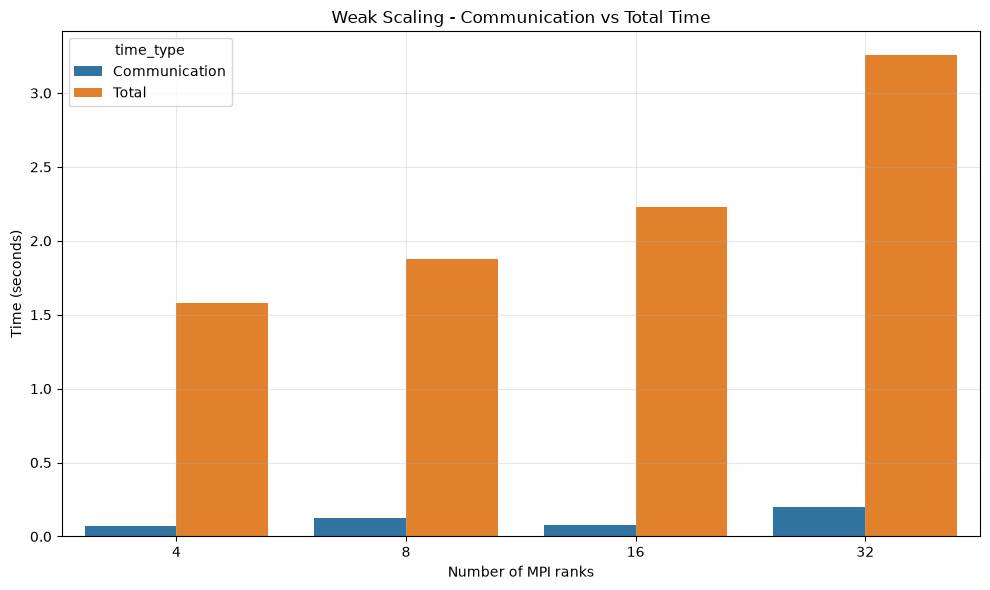

In [ ]:
plot_data = results.melt(
    id_vars=["n_bits", "n_key", "n_ranks", "n_threads"],
    value_vars=[
        "time_communication_seconds",
        "time_total_seconds"
    ],
    var_name="time_type",
    value_name="time_seconds"
)

plot_data["time_type"] = plot_data["time_type"].map({
    "time_communication_seconds": "Communication",
    "time_total_seconds": "Total"
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="n_ranks",
    y="time_seconds",
    hue="time_type",
    errorbar=None
)

plt.xlabel("Number of MPI ranks")
plt.ylabel("Time (seconds)")
plt.title("Weak Scaling - Communication vs Total Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()